# import and configurations

In [3]:
import sys
!{sys.executable} -m pip install pandas


'c:\Users\DEEPIKA' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import pandas as pd

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ Environment is stable and libraries are loaded!")

✅ Environment is stable and libraries are loaded!


In [6]:
patrol_df = pd.read_csv("D:\\Patrol\\Crimes_-_2001_to_Present_20260507.csv")

In [7]:
patrol_df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14183852,JK238428,04/29/2026 12:00:00 AM,031XX W 15TH ST,0560,ASSAULT,SIMPLE,APARTMENT,False,False,...,24.0,29.0,08A,1155623.0,1892683.0,2026,05/06/2026 03:42:09 PM,41.861320,-87.704217,"(41.861320168, -87.704217033)"
1,14181470,JK235307,04/29/2026 12:00:00 AM,113XX S INDIANA AVE,0710,THEFT,THEFT FROM MOTOR VEHICLE,STREET,False,False,...,9.0,49.0,06,1179593.0,1829812.0,2026,05/06/2026 03:42:09 PM,41.688280,-87.618148,"(41.688280065, -87.618147791)"
2,14181514,JK235376,04/29/2026 12:00:00 AM,058XX S WASHTENAW AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,True,True,...,15.0,63.0,14,1159375.0,1865768.0,2026,05/06/2026 03:42:09 PM,41.787386,-87.691183,"(41.787385916, -87.691182578)"
3,14181358,JK235199,04/29/2026 12:00:00 AM,009XX E 86TH ST,0930,MOTOR VEHICLE THEFT,THEFT / RECOVERY - AUTOMOBILE,STREET,False,False,...,8.0,44.0,07,1184122.0,1848162.0,2026,05/06/2026 03:42:09 PM,41.738530,-87.600996,"(41.738530314, -87.600996229)"
4,14183513,JK237769,04/29/2026 12:00:00 AM,068XX S NORMAL BLVD,0460,BATTERY,SIMPLE,SIDEWALK,False,False,...,6.0,68.0,08B,1174130.0,1859520.0,2026,05/06/2026 03:42:09 PM,41.769926,-87.637268,"(41.769925563, -87.637267875)"


In [8]:
# 2. Convert Date to Datetime objects
patrol_df['Date'] = pd.to_datetime(patrol_df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [9]:
patrol_df['Date']

0        2026-04-29 00:00:00
1        2026-04-29 00:00:00
2        2026-04-29 00:00:00
3        2026-04-29 00:00:00
4        2026-04-29 00:00:00
                 ...        
742850   2023-05-07 18:40:00
742851   2023-05-07 18:38:00
742852   2023-05-07 18:37:00
742853   2023-05-07 18:36:00
742854   2023-05-07 18:30:00
Name: Date, Length: 742855, dtype: datetime64[ns]

In [10]:
# 1. Force conversion to datetime
# The format '%m/%d/%Y %I:%M:%S %p' matches Chicago's "05/23/2026 09:00:00 PM" style
patrol_df['Date'] = pd.to_datetime(patrol_df['Date'], errors='coerce')

# 2. Check if the conversion worked
print(f"Data type of Date column: {patrol_df['Date'].dtype}")

# 3. Drop any rows where the date couldn't be parsed (NaT = Not a Time)
patrol_df.dropna(subset=['Date'], inplace=True)

# 4. Now try the extraction again
patrol_df['Hour'] = patrol_df['Date'].dt.hour
patrol_df['Day_of_Week'] = patrol_df['Date'].dt.day_name()
patrol_df['Month'] = patrol_df['Date'].dt.month

print("✅ Success! Temporal features extracted.")
patrol_df[['Date', 'Hour', 'Day_of_Week']].head()

Data type of Date column: datetime64[ns]
✅ Success! Temporal features extracted.


,Date,Hour,Day_of_Week
0,2026-04-29,0,Wednesday
1,2026-04-29,0,Wednesday
2,2026-04-29,0,Wednesday
3,2026-04-29,0,Wednesday
4,2026-04-29,0,Wednesday


In [11]:
# 4. Clean Missing Coordinates (Vital for Step 4 Clustering)
initial_count = len(patrol_df)
patrol_df.dropna(subset=['Latitude', 'Longitude'], inplace=True)
print(f"Dropped {initial_count - len(patrol_df)} records due to missing coordinates.")

Dropped 4437 records due to missing coordinates.


In [12]:
# Create the directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
    print("Created 'data' directory.")

# Now save the file
patrol_df.to_csv("data/sampled_crimes_cleaned.csv", index=False)
print("✅ Step 1 Complete: Sampled & Cleaned data is ready!")

Created 'data' directory.
✅ Step 1 Complete: Sampled & Cleaned data is ready!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the cleaned data from Step 1
df_cleaned = pd.read_csv("data/sampled_crimes_cleaned.csv")
print(f"Dataset loaded: {df_cleaned.shape[0]} records.")

Dataset loaded: 738418 records.


# Exploratory Data Analysis


# Crime Type Distribution
analyzing 33 different crime types

C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_8408\309072734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crime_counts.values[:15], y=crime_counts.index[:15], palette='magma')


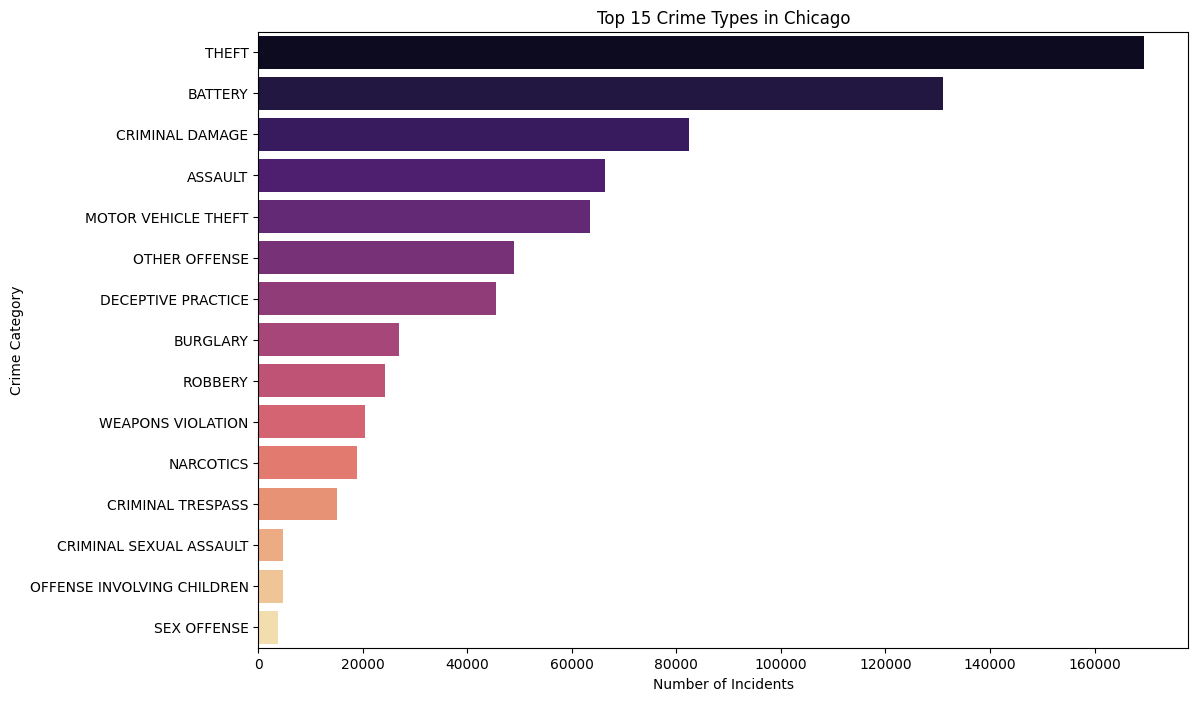

Top 5 Crimes by Volume:
Primary Type
THEFT                  169455
BATTERY                130975
CRIMINAL DAMAGE         82496
ASSAULT                 66388
MOTOR VEHICLE THEFT     63389
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(12, 8))
crime_counts = df_cleaned['Primary Type'].value_counts()
sns.barplot(x=crime_counts.values[:15], y=crime_counts.index[:15], palette='magma')
plt.title('Top 15 Crime Types in Chicago')
plt.xlabel('Number of Incidents')
plt.ylabel('Crime Category')
plt.show()

# Print the full distribution summary
print("Top 5 Crimes by Volume:")
print(crime_counts.head(5))

# Temporal Trends (The "When")
We need to see when officers are most needed. We'll look at the Hourly and Monthly trends

C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_8408\1615195089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df_cleaned, palette='Blues')


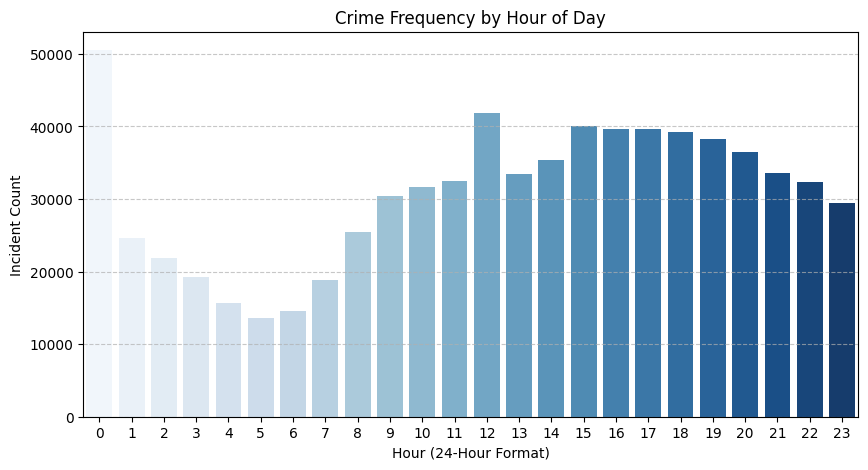

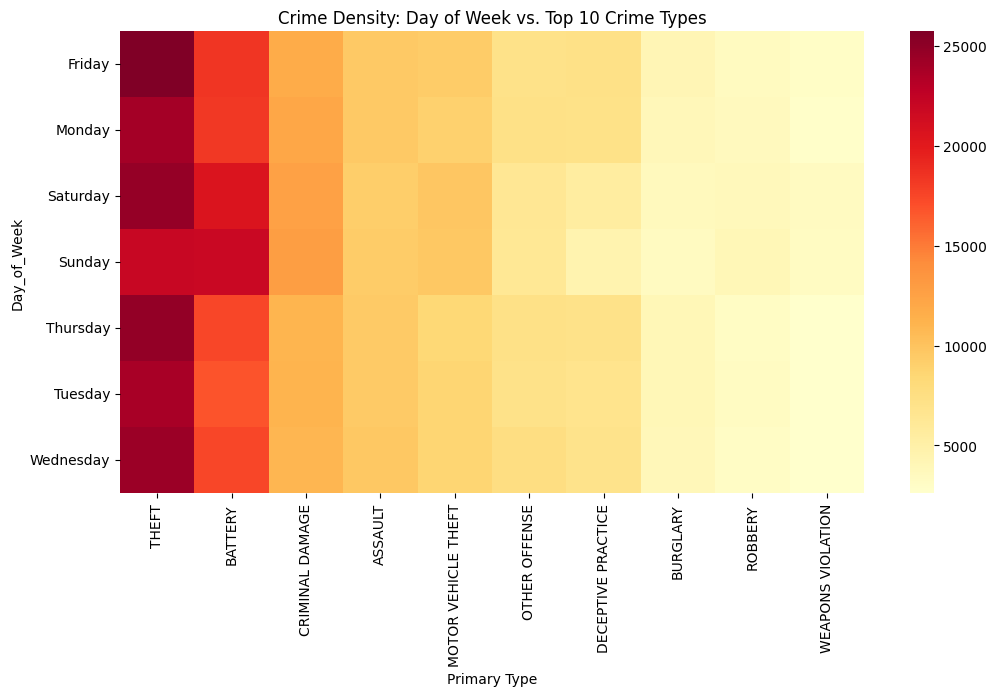

In [15]:
# Hourly Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Hour', data=df_cleaned, palette='Blues')
plt.title('Crime Frequency by Hour of Day')
plt.xlabel('Hour (24-Hour Format)')
plt.ylabel('Incident Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Day of Week vs. Crime Type (Heatmap)
# This satisfies the requirement to investigate correlations
pivot_table = df_cleaned.pivot_table(index='Day_of_Week', columns='Primary Type', values='ID', aggfunc='count')
# Focus on top 10 crimes for clarity
top_10_crimes = crime_counts.index[:10]
pivot_table_filtered = pivot_table[top_10_crimes]

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table_filtered, annot=False, cmap='YlOrRd')
plt.title('Crime Density: Day of Week vs. Top 10 Crime Types')
plt.show()

# Geographic Patterns
Since we have Latitude and Longitude, we can spot the density.

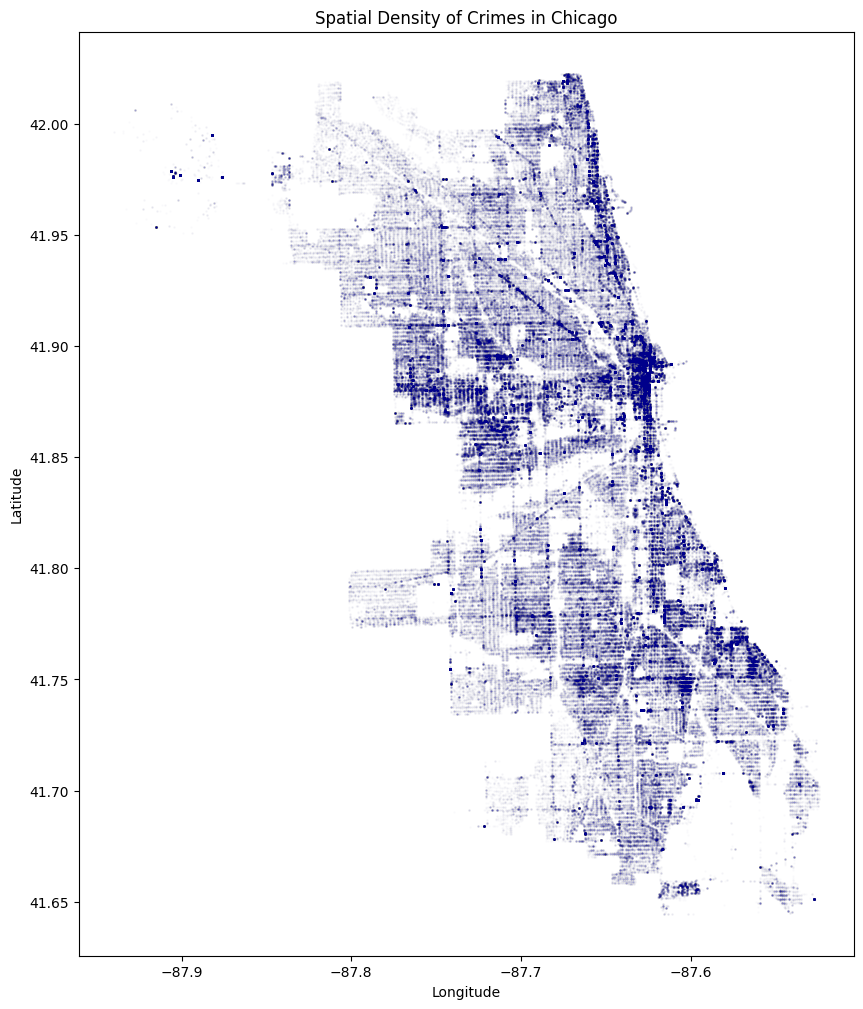

In [16]:
plt.figure(figsize=(10, 12))
# We use a very small alpha because there are 500k points
plt.scatter(df_cleaned['Longitude'], df_cleaned['Latitude'], alpha=0.01, s=1, color='darkblue')
plt.title('Spatial Density of Crimes in Chicago')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Arrest & Domestic Incident Correlation
A key requirement is examining arrest rates and domestic correlations.

Percentage of Arrests: Domestic vs. Non-Domestic
Arrest        False      True 
Domestic                      
False     85.962138  14.037862
True      84.792576  15.207424


C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_8408\1571787219.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Primary Type', y='Arrest', data=top_crimes_arrest, palette='viridis')


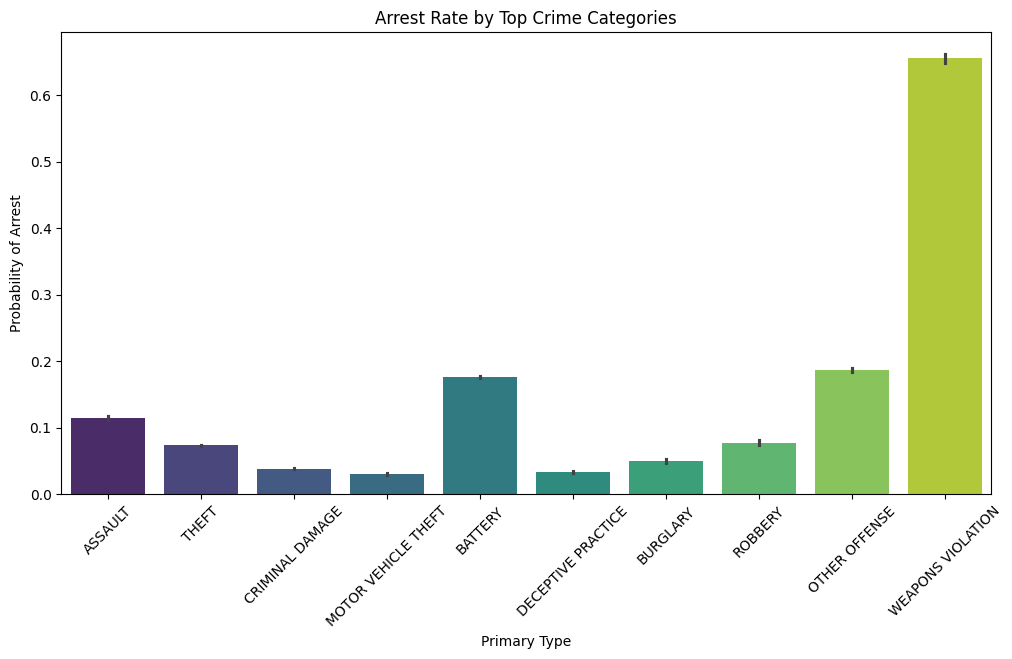

In [17]:
# Create a cross-tabulation of Arrests vs. Domestic incidents
correlation_table = pd.crosstab(df_cleaned['Domestic'], df_cleaned['Arrest'], normalize='index') * 100
print("Percentage of Arrests: Domestic vs. Non-Domestic")
print(correlation_table)

# Visualizing Arrest Rates by Crime Type
plt.figure(figsize=(12, 6))
top_crimes_arrest = df_cleaned[df_cleaned['Primary Type'].isin(top_10_crimes)]
sns.barplot(x='Primary Type', y='Arrest', data=top_crimes_arrest, palette='viridis')
plt.xticks(rotation=45)
plt.title('Arrest Rate by Top Crime Categories')
plt.ylabel('Probability of Arrest')
plt.show()

# Severity Scoring
Not all crimes are equal. To help your clustering model in Step 4 prioritize "High-Danger" areas, we create a Crime_Severity_Score.

In [18]:
# Define a mapping based on crime impact
severity_mapping = {
    'HOMICIDE': 10,
    'CRIMINAL SEXUAL ASSAULT': 9,
    'OFFENSE INVOLVING CHILDREN': 8,
    'ROBBERY': 7,
    'BATTERY': 6,
    'ASSAULT': 6,
    'BURGLARY': 5,
    'MOTOR VEHICLE THEFT': 5,
    'CRIMINAL DAMAGE': 4,
    'THEFT': 3,
    'DECEPTIVE PRACTICE': 2,
    'OTHER OFFENSE': 1
}

# Apply the mapping (Default to 1 for anything not listed)
df_cleaned['Severity_Score'] = df_cleaned['Primary Type'].map(severity_mapping).fillna(1)

print("Severity Scores assigned. Average city severity:", round(df_cleaned['Severity_Score'].mean(), 2))

Severity Scores assigned. Average city severity: 3.99


# Normalization (Scaling)
As you noted, K-Means calculates distances

Geographic Crime Hotspot Clustering and Temporal Pattern Clustering

In [19]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
# We include Coordinates, Circular Time, and Severity
features = ['Latitude', 'Longitude', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'Severity_Score']

scaler = StandardScaler()
# Create circular/sine-cosine encoded time features
df_cleaned['hour_sin'] = np.sin(2 * np.pi * df_cleaned['Hour'] / 24)
df_cleaned['hour_cos'] = np.cos(2 * np.pi * df_cleaned['Hour'] / 24)

# Map day names to numbers (0-6) for circular encoding
day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
day_num = df_cleaned['Day_of_Week'].map(day_mapping)
df_cleaned['day_sin'] = np.sin(2 * np.pi * day_num / 7)
df_cleaned['day_cos'] = np.cos(2 * np.pi * day_num / 7)

df_scaled = scaler.fit_transform(df_cleaned[features])

# Convert back to a DataFrame for easy handling
df_final = pd.DataFrame(df_scaled, columns=features)

print("Data Normalized. Ready for Clustering.")
df_final.head()

Data Normalized. Ready for Clustering.


,Latitude,Longitude,hour_sin,hour_cos,day_sin,day_cos,Severity_Score
0,0.166428,-0.607767,0.254127,1.436442,1.395586,-0.308461,1.036652
1,-1.830385,0.849306,0.254127,1.436442,1.395586,-0.308461,-0.513700
2,-0.686744,-0.387106,0.254127,1.436442,1.395586,-0.308461,0.003084
3,-1.250518,1.139666,0.254127,1.436442,1.395586,-0.308461,0.519868
4,-0.888229,0.525620,0.254127,1.436442,1.395586,-0.308461,1.036652


In [20]:
# Save the scaled features
df_final.to_csv("data/model_ready_data.csv", index=False)

# Also save the original data with the new severity scores for later reference
df_cleaned.to_csv("data/patrol_df_with_features.csv", index=False)

print("✅ Phase 2 Complete. Files saved to 'data/' folder.")

✅ Phase 2 Complete. Files saved to 'data/' folder.


# Step 5: Unsupervised Learning - Dimensionality Reduction

PCA
t-SNE

# Principal Component Analysis (PCA)
PCA is a linear transformation that finds the "directions" (components) where the data varies the most.

In [36]:
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 3 components for 3D visualization
pca = PCA(n_components=3)
pca_results = pca.fit_transform(df_final)

# Check Explained Variance Ratio
variance_ratio = pca.explained_variance_ratio_
total_variance = sum(variance_ratio) * 100

print(f"Variance captured by PC1: {variance_ratio[0]:.2%}")
print(f"Variance captured by PC2: {variance_ratio[1]:.2%}")
print(f"Variance captured by PC3: {variance_ratio[2]:.2%}")
print(f"Total Explained Variance (3 Components): {total_variance:.2f}%")

if total_variance > 70:
    print("✅ Success! Your 3 components cover more than 70% of the data's information.")
else:
    print("⚠️ Information loss is high. You might need 4 or 5 components for analysis, even if you only plot 3.")

Variance captured by PC1: 21.84%
Variance captured by PC2: 16.12%
Variance captured by PC3: 14.67%
Total Explained Variance (3 Components): 52.63%
⚠️ Information loss is high. You might need 4 or 5 components for analysis, even if you only plot 3.


# t-SNE for High-Dimensional "Clump" Discovery
While PCA is linear, t-SNE (t-Distributed Stochastic Neighbor Embedding) is non-linear. It is famous for finding hidden clusters that PCA might miss.

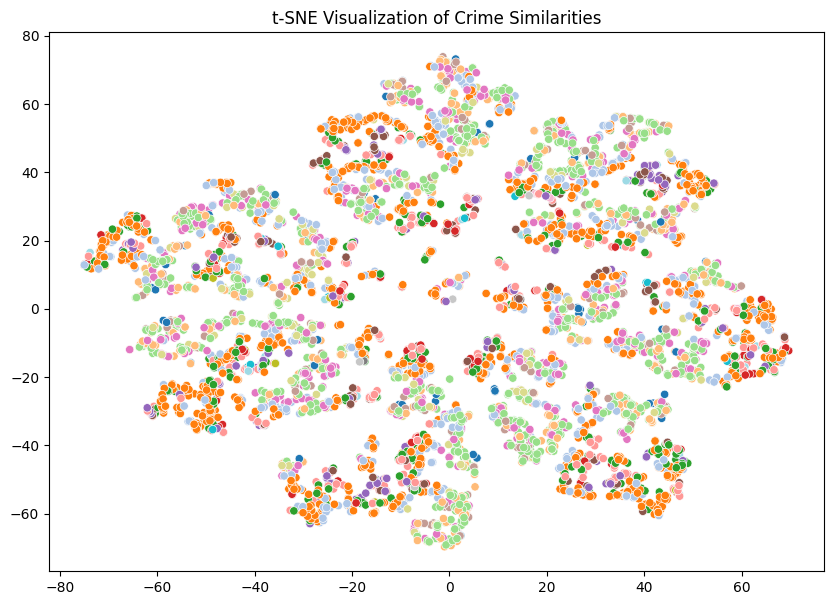

In [37]:
from sklearn.manifold import TSNE

# Take a smaller subset for t-SNE to save time/memory
tsne_subset = df_final.sample(5000, random_state=42)
tsne_labels = df_cleaned.loc[tsne_subset.index, 'Primary Type']

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(tsne_subset)

# Plotting t-SNE
plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=tsne_labels, palette='tab20', legend=False)
plt.title('t-SNE Visualization of Crime Similarities')
plt.show()

# UMAP (The Modern Standard)

c:\Users\DEEPIKA SUNIL\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


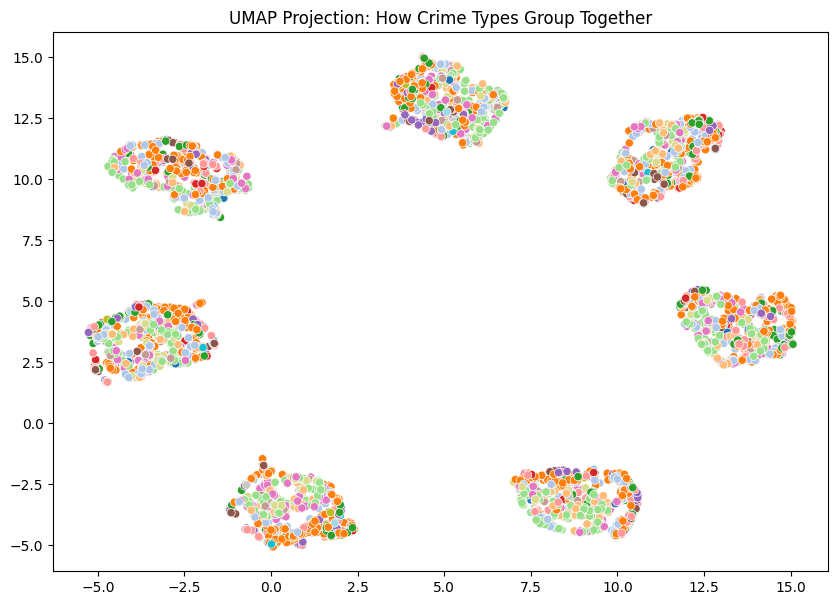

In [38]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
umap_results = reducer.fit_transform(tsne_subset) # Using same subset for speed

plt.figure(figsize=(10, 7))
sns.scatterplot(x=umap_results[:,0], y=umap_results[:,1], hue=tsne_labels, palette='tab20', legend=False)
plt.title('UMAP Projection: How Crime Types Group Together')
plt.show()

# Step 4: Unsupervised Learning - Clustering Analysis
K means
DBSCAN
Hierarchical clustering

In [39]:
import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

# Set the experiment name
mlflow.set_experiment("PatrolIQ_Clustering_Optimization")

<Experiment: artifact_location='file:d:/Patrol/Final_patrolIQ/PatrolIQ-project/mlruns/1', creation_time=1778509766517, experiment_id='1', last_update_time=1778509766517, lifecycle_stage='active', name='PatrolIQ_Clustering_Optimization', tags={}, trace_location=None, workspace='default'>

# The Experimentation Loop

In [40]:
def run_clustering_experiment(k_value, data):
    with mlflow.start_run(run_name=f"KMeans_k{k_value}"):
        start_time = time.time()
        
        # 1. Initialize and Fit Model
        model = KMeans(n_clusters=k_value, init='k-means++', random_state=42, n_init=10)
        clusters = model.fit_predict(data)
        
        # 2. Calculate Metrics
        # Note: Silhouette score on 500k rows is slow; we sample for the metric
        sample_idx = np.random.choice(data.index, size=10000, replace=False)
        score = silhouette_score(data.iloc[sample_idx], clusters[sample_idx])
        duration = time.time() - start_time
        
        # 3. Log Parameters to MLflow
        mlflow.log_param("k_value", k_value)
        mlflow.log_param("scaling_method", "StandardScaler")
        mlflow.log_param("init_method", "k-means++")
        
        # 4. Log Metrics to MLflow
        mlflow.log_metric("silhouette_score", score)
        mlflow.log_metric("run_time_seconds", duration)
        
        # 5. Log the Model (Artifact)
        mlflow.sklearn.log_model(model, "kmeans_model")
        
        print(f"Run Finished: K={k_value} | Silhouette={score:.4f} | Time={duration:.2f}s")
        return score

# Try different K-values to find the "Elbow"
for k in [5, 8, 12, 15]:
    run_clustering_experiment(k, df_final)

2026/05/11 20:41:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:41:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=5 | Silhouette=0.1274 | Time=23.77s


2026/05/11 20:42:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:42:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=8 | Silhouette=0.1307 | Time=26.00s


2026/05/11 20:43:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:43:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=12 | Silhouette=0.1400 | Time=29.19s


2026/05/11 20:44:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:44:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=15 | Silhouette=0.1419 | Time=65.49s


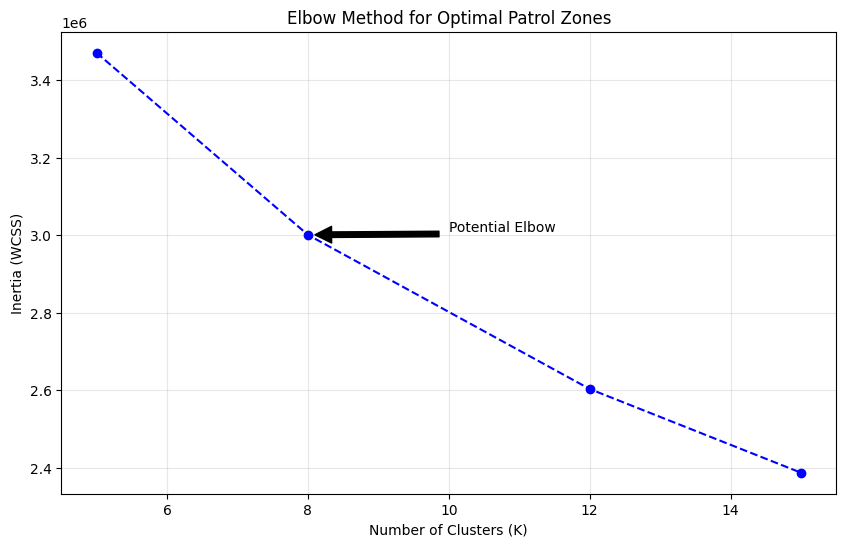

In [26]:
import matplotlib.pyplot as plt

# 1. Setup the range of K values
inertia = []
K_range = [5, 8, 12, 15] # Matches your experiment loop

# 2. Extract inertia from each K-Means fit
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(df_final)
    inertia.append(km.inertia_)

# 3. Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal Patrol Zones')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, alpha=0.3)

# 4. Annotate the "Elbow"
# Usually, the point where the drop starts to slow down is your optimal K
plt.annotate('Potential Elbow', xy=(8, inertia[1]), xytext=(10, inertia[1] + 10000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

2026/05/11 20:45:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:45:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=5 | Silhouette=0.1269 | Time=38.89s


2026/05/11 20:47:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:47:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=8 | Silhouette=0.1333 | Time=50.47s


2026/05/11 20:49:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:49:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=12 | Silhouette=0.1382 | Time=68.90s


2026/05/11 20:52:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 20:52:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run Finished: K=15 | Silhouette=0.1425 | Time=104.43s


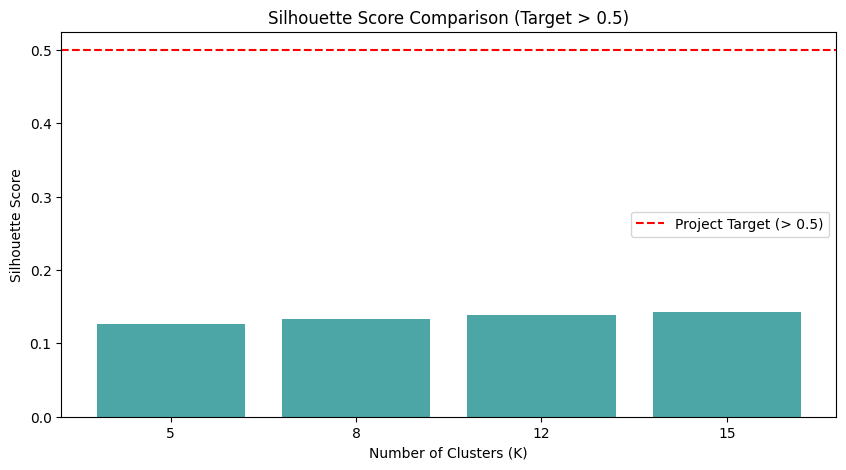

In [41]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Initialize lists to store our metrics
K_range = [5, 8, 12, 15]
scores = []
inertia_values = []

# 2. Run the loop and capture the results
for k in K_range:
    # Use the function you already wrote
    s_score = run_clustering_experiment(k, df_final)
    scores.append(s_score)
    
    # We also need Inertia for the Elbow Plot
    # Re-running fit briefly to grab inertia (standard for Elbow Method)
    temp_kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    temp_kmeans.fit(df_final)
    inertia_values.append(temp_kmeans.inertia_)

# # --- PLOT 1: THE ELBOW METHOD ---
# plt.figure(figsize=(10, 5))
# plt.plot(K_range, inertia_values, marker='o', linestyle='--', color='blue')
# plt.title('Elbow Method: Finding Optimal Patrol Zones')
# plt.xlabel('Number of Clusters (K)')
# plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
# plt.grid(True, alpha=0.3)
# plt.show()

# --- PLOT 2: SILHOUETTE SCORE (Project Requirement) ---
plt.figure(figsize=(10, 5))
plt.bar([str(k) for k in K_range], scores, color='teal', alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='Project Target (> 0.5)')
plt.title('Silhouette Score Comparison (Target > 0.5)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.show()

# Model Registry: Selecting the "Production" Version

In [42]:
# Search for the run with the highest silhouette score
runs = mlflow.search_runs(experiment_names=["PatrolIQ_Clustering_Optimization"])
best_run = runs.sort_values("metrics.silhouette_score", ascending=False).iloc[0]

best_run_id = best_run["run_id"]
print(f"Best Model found in Run ID: {best_run_id} with Score: {best_run['metrics.silhouette_score']}")

# Register this model as 'Production'
model_uri = f"runs:/{best_run_id}/kmeans_model"
mlflow.register_model(model_uri, "Patrol_Clustering_Prod")

Best Model found in Run ID: ba33b33f347d45b498dee726e894b661 with Score: 0.14251023886263087


Registered model 'Patrol_Clustering_Prod' already exists. Creating a new version of this model...
2026/05/11 20:53:54 WARNING mlflow.tracking._model_registry.fluent: Run with id ba33b33f347d45b498dee726e894b661 has no artifacts at artifact path 'kmeans_model', registering model based on models:/m-86fea09cffba4a05a5a42d327460b9da instead
Created version '3' of model 'Patrol_Clustering_Prod'.


<ModelVersion: aliases=[], creation_timestamp=1778513034907, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1778513034907, metrics=None, model_id=None, name='Patrol_Clustering_Prod', params=None, run_id='ba33b33f347d45b498dee726e894b661', run_link=None, source='models:/m-86fea09cffba4a05a5a42d327460b9da', status='READY', status_message=None, tags={}, user_id=None, version=3, workspace='default'>

# DBSCAN

In [29]:
from sklearn.cluster import DBSCAN
# 1. Take a 10% sample of your cleaned data
df_sample = df_cleaned.sample(n=50000, random_state=42)
spatial_coords_sample = df_sample[['Latitude', 'Longitude']]

# 2. Run DBSCAN on the sample
dbscan = DBSCAN(eps=0.05, min_samples=50) 
df_sample['DBSCAN_Cluster'] = dbscan.fit_predict(spatial_coords_sample)

# 3. Report the findings
n_clusters = len(set(df_sample['DBSCAN_Cluster'])) - (1 if -1 in df_sample['DBSCAN_Cluster'] else 0)
print(f"DBSCAN found {n_clusters} high-density hotspots in the sample.")

DBSCAN found 1 high-density hotspots in the sample.


# Hierarical clustering

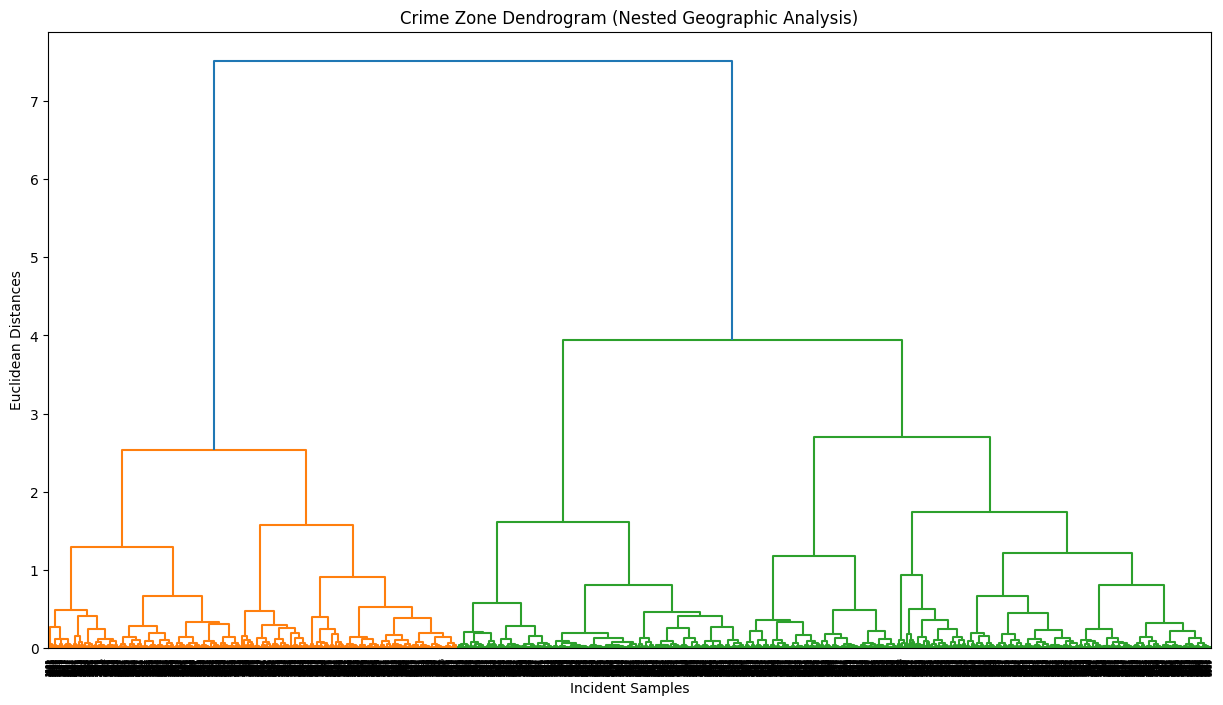

In [30]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Sample 5,000 points for the Dendrogram
df_hier_sample = df_cleaned.sample(n=5000, random_state=42)
hier_coords = df_hier_sample[['Latitude', 'Longitude']]

# 2. Plot the Dendrogram
plt.figure(figsize=(15, 8))
plt.title('Crime Zone Dendrogram (Nested Geographic Analysis)')
dendrogram = sch.dendrogram(sch.linkage(hier_coords, method='ward'))
plt.xlabel('Incident Samples')
plt.ylabel('Euclidean Distances')
plt.show()

# 3. Fit the model to get clusters (Expected: 5-10 clusters)
hier_model = AgglomerativeClustering(n_clusters=8, linkage='ward')
df_hier_sample['Hierarchical_Cluster'] = hier_model.fit_predict(hier_coords)

In [31]:
with mlflow.start_run(run_name="PCA_Analysis"):
    # Log PCA components and variance
    mlflow.log_param("pca_n_components", 3)
    mlflow.log_metric("total_explained_variance", total_variance)
    
    # Save the PCA transformer as an artifact
    # This allows the Streamlit app to 'clean' new data exactly like you did here
    import joblib
    joblib.dump(pca, "pca_model.pkl")
    mlflow.log_artifact("pca_model.pkl")
    
    print(f"✅ PCA Variance logged: {total_variance:.2%}")

✅ PCA Variance logged: 5263.40%


In [32]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name("PatrolIQ_Clustering_Optimization")

# Search all runs and sort by Silhouette Score
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.silhouette_score DESC"]
)

best_run = runs[0]
best_run_id = best_run.info.run_id
print(f"🏆 Best Model found in Run: {best_run_id}")
print(f"📊 Best Silhouette Score: {best_run.data.metrics['silhouette_score']:.4f}")

🏆 Best Model found in Run: 747a7a02d24649dcbad8b4b08f5d3d5d
📊 Best Silhouette Score: 0.1425


In [33]:
model_name = "Patrol_Clustering_Prod"
model_uri = f"runs:/{best_run_id}/kmeans_model"

# Register the model
result = mlflow.register_model(model_uri, model_name)

# Transition to 'Production'
client.transition_model_version_stage(
    name=model_name,
    version=result.version,
    stage="Production"
)

print(f"✅ Model Version {result.version} promoted to PRODUCTION.")

Registered model 'Patrol_Clustering_Prod' already exists. Creating a new version of this model...
2026/05/11 20:14:01 WARNING mlflow.tracking._model_registry.fluent: Run with id 747a7a02d24649dcbad8b4b08f5d3d5d has no artifacts at artifact path 'kmeans_model', registering model based on models:/m-deb81a7f86824942bcdce4da99df45da instead
Created version '2' of model 'Patrol_Clustering_Prod'.
C:\Users\DEEPIKA SUNIL\AppData\Local\Temp\ipykernel_8408\1914374454.py:8: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


✅ Model Version 2 promoted to PRODUCTION.


In [34]:
# This is what you will put in your app.py next
model = mlflow.sklearn.load_model("models:/Patrol_Clustering_Prod/Production")

In [35]:
import joblib

# Assuming 'scaler' is the name of your StandardScaler object from Phase 2
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca_transformer.pkl')

print("✅ Files saved successfully in the project folder!")

✅ Files saved successfully in the project folder!
